In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as mp
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
import joblib

In [ ]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [ ]:
df.shape

(400, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
df.dtypes

,0
User ID,int64
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [ ]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

/tmp/ipykernel_1028/2063836454.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [ ]:

df.corr(numeric_only=True)

,User ID,Gender,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.025249,-0.000721,0.071097,0.007120
Gender,-0.025249,1.000000,-0.073741,-0.060435,-0.042469
Age,-0.000721,-0.073741,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,-0.060435,0.155238,1.000000,0.362083
Purchased,0.007120,-0.042469,0.622454,0.362083,1.000000


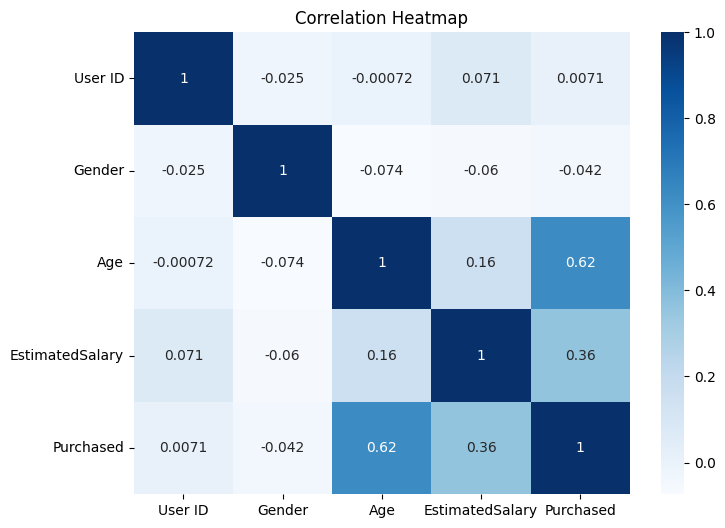

In [ ]:
import matplotlib.pyplot as mp
import seaborn as sns

mp.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
           annot=True,
           cmap="Blues")

mp.title("Correlation Heatmap")

mp.show()

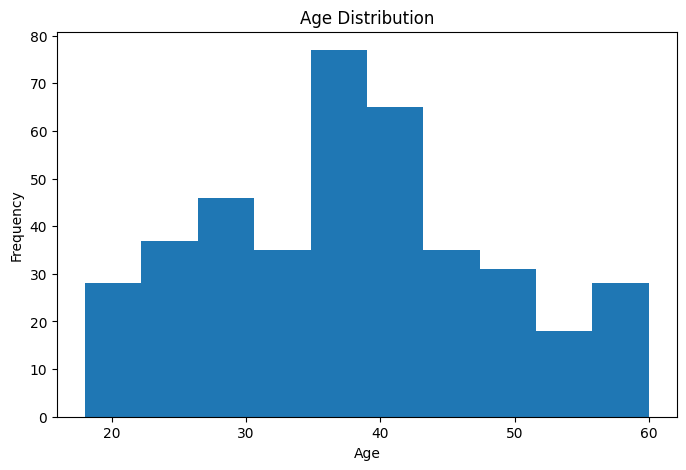

In [ ]:
mp.figure(figsize=(8,5))

mp.hist(df["Age"], bins=10)

mp.title("Age Distribution")

mp.xlabel("Age")

mp.ylabel("Frequency")

mp.show()

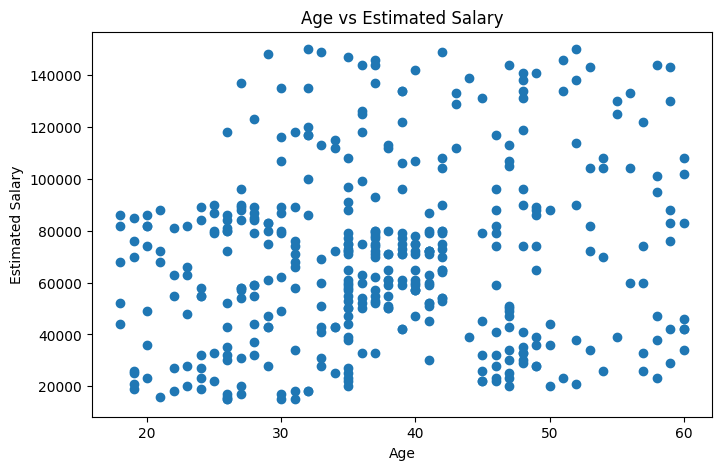

In [ ]:
mp.figure(figsize=(8,5))

mp.scatter(df["Age"],
           df["EstimatedSalary"])

mp.title("Age vs Estimated Salary")

mp.xlabel("Age")

mp.ylabel("Estimated Salary")

mp.show()

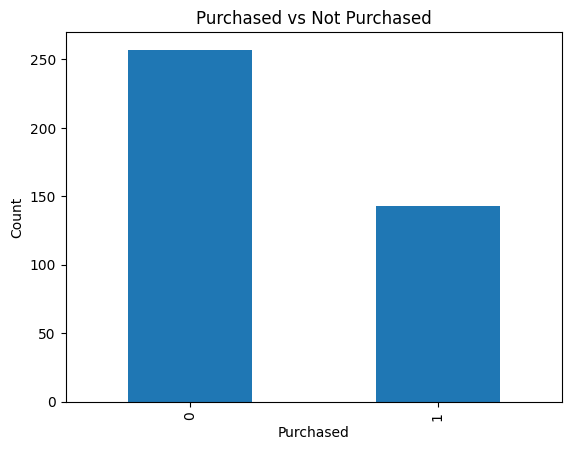

In [ ]:
df["Purchased"].value_counts().plot(kind="bar")

mp.title("Purchased vs Not Purchased")

mp.xlabel("Purchased")

mp.ylabel("Count")

mp.show()

In [ ]:
X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (320, 3)
Testing Data : (80, 3)


In [37]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [40]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [42]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred)
    ]
})
results


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8875,0.913043,0.750000,0.823529
1,KNN,0.9250,0.866667,0.928571,0.896552
2,Decision Tree,0.8500,0.807692,0.750000,0.777778


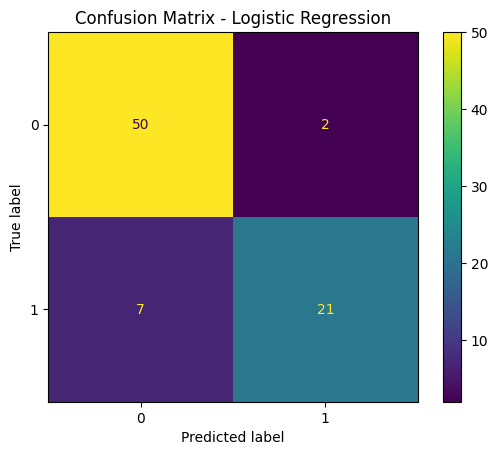

In [43]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

mp.title("Confusion Matrix - Logistic Regression")

mp.show()

In [44]:
joblib.dump(lr, "best_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [45]:
def predict_customer(gender, age, salary):

    data = pd.DataFrame([[gender, age, salary]],
                        columns=["Gender", "Age", "EstimatedSalary"])

    data = scaler.transform(data)

    prediction = lr.predict(data)

    if prediction[0] == 1:
        return "Customer is likely to Purchase the Product."
    else:
        return "Customer is Not likely to Purchase the Product."

In [46]:
predict_customer(1, 30, 50000)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


'Customer is likely to Purchase the Product.'

In [47]:
predict_customer(0, 45, 90000)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


'Customer is likely to Purchase the Product.'